<a href="https://colab.research.google.com/github/AvichalTrivedi7/IIT-Roorkee_InternshipWork/blob/main/Module_4_(Exercise_4_3)_IITR_Internship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# Setup Kaggle

import json
import os

kaggle_creds = {
    "username": "avichalt",
    "key": "KGAT_a4fa49d2d850b09564a552b790ea9a13"
}

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    json.dump(kaggle_creds, f)

os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
print("kaggle.json created manually.")

kaggle.json created manually.


In [9]:
# Download CelebA

!kaggle datasets download -d jessicali9530/celeba-dataset -p ./data/celeba --unzip
print("Download complete.")

Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other
100% 1.33G/1.33G [00:17<00:00, 83.6MB/s]

Download complete.


In [16]:
# Check Structure

import os

print("./data/celeba:")
print(os.listdir('./data/celeba'))

print("\n./data/celeba/celeba:")
print(os.listdir('./data/celeba/celeba'))

./data/celeba:
['celeba']

./data/celeba/celeba:
['list_landmarks_align_celeba.txt', 'list_bbox_celeba.txt', 'list_attr_celeba.txt', 'img_align_celeba', 'list_eval_partition.txt']


In [13]:
# Moving files to where torchvision expects them

import os
import shutil

os.makedirs('./data/celeba/celeba', exist_ok=True)

for f in os.listdir('./data/celeba'):
    if f != 'celeba':   # don't move the folder itself
        shutil.move(f'./data/celeba/{f}',
                    f'./data/celeba/celeba/{f}')

print(os.listdir('./data/celeba/celeba'))

rename_map = {
    'list_attr_celeba.csv':              'list_attr_celeba.txt',
    'list_eval_partition.csv':           'list_eval_partition.txt',
    'list_bbox_celeba.csv':              'list_bbox_celeba.txt',
    'list_landmarks_align_celeba.csv':   'list_landmarks_align_celeba.txt'
}

base = './data/celeba/celeba'
for old, new in rename_map.items():
    old_path = os.path.join(base, old)
    new_path = os.path.join(base, new)
    if os.path.exists(old_path):
        os.rename(old_path, new_path)
        print(f"Renamed {old} → {new}")

print("\nFinal structure:")
print(os.listdir('./data/celeba/celeba'))

['list_eval_partition.csv', 'list_attr_celeba.csv', 'list_bbox_celeba.csv', 'img_align_celeba', 'list_landmarks_align_celeba.csv']
Renamed list_attr_celeba.csv → list_attr_celeba.txt
Renamed list_eval_partition.csv → list_eval_partition.txt
Renamed list_bbox_celeba.csv → list_bbox_celeba.txt
Renamed list_landmarks_align_celeba.csv → list_landmarks_align_celeba.txt

Final structure:
['list_landmarks_align_celeba.txt', 'list_bbox_celeba.txt', 'list_attr_celeba.txt', 'img_align_celeba', 'list_eval_partition.txt']


In [20]:
# Some more fixes

import os

# Create a dummy identity file with one identity per image
# CelebA has 202599 images total
n_images = 202599
identity_path = './data/celeba/celeba/identity_CelebA.txt'

with open(identity_path, 'w') as f:
    for i in range(1, n_images + 1):
        f.write(f'{i:06d}.jpg {i}\n')

print("Created identity_CelebA.txt")
print(os.listdir('./data/celeba/celeba'))

Created identity_CelebA.txt
['list_landmarks_align_celeba.txt', 'list_bbox_celeba.txt', 'list_attr_celeba.txt', 'img_align_celeba', 'list_eval_partition.txt', 'identity_CelebA.txt']


In [22]:
# More fixes

n_images = 202598   # one less

identity_path = './data/celeba/celeba/identity_CelebA.txt'
with open(identity_path, 'w') as f:
    for i in range(1, n_images + 1):
        f.write(f'{i:06d}.jpg {i}\n')

print("Fixed identity_CelebA.txt")

Fixed identity_CelebA.txt


In [25]:
# Just two more
n_images = 202600

identity_path = './data/celeba/celeba/identity_CelebA.txt'
with open(identity_path, 'w') as f:
    for i in range(1, n_images + 1):
        f.write(f'{i:06d}.jpg {i}\n')

print("Fixed identity_CelebA.txt")

Fixed identity_CelebA.txt


In [28]:
# Last fix for sure
import os

# Fix list_eval_partition.txt
with open('./data/celeba/celeba/list_eval_partition.txt') as f:
    lines = f.readlines()

# Remove header, convert comma to space
with open('./data/celeba/celeba/list_eval_partition.txt', 'w') as f:
    for line in lines[1:]:   # skip header
        parts = line.strip().split(',')
        f.write(f'{parts[0]} {parts[1]}\n')

print("Fixed list_eval_partition.txt")

# Check attr file format
with open('./data/celeba/celeba/list_attr_celeba.txt') as f:
    attr_lines = f.readlines()

print(f"\nAttr file first 3 lines:")
for l in attr_lines[:3]:
    print(repr(l))

Fixed list_eval_partition.txt

Attr file first 3 lines:
'image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,Blond_Hair,Blurry,Brown_Hair,Bushy_Eyebrows,Chubby,Double_Chin,Eyeglasses,Goatee,Gray_Hair,Heavy_Makeup,High_Cheekbones,Male,Mouth_Slightly_Open,Mustache,Narrow_Eyes,No_Beard,Oval_Face,Pale_Skin,Pointy_Nose,Receding_Hairline,Rosy_Cheeks,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young\n'
'000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,-1,-1,1,-1,-1,-1,-1,-1,-1,1,1,-1,1,-1,-1,1,-1,-1,1,-1,-1,-1,1,1,-1,1,-1,1,-1,-1,1\n'
'000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,-1,-1,1,-1,-1,-1,-1,-1,-1,-1,1,-1,1,-1,-1,1,-1,-1,-1,-1,-1,-1,1,-1,-1,-1,-1,-1,-1,-1,1\n'


In [31]:
# Done

import os
import pandas as pd

base = './data/celeba/celeba'

# ── 1. list_eval_partition.txt — already space-separated but missing one line
# It has 202599, needs 202600. The header was removed but we need 202599 data lines
# Actually it's fine — let's re-examine. Add missing last image:
with open(os.path.join(base, 'list_eval_partition.txt')) as f:
    lines = f.readlines()
# Add the missing 202599.jpg as test (partition 2)
lines.append('202599.jpg 2\n')
with open(os.path.join(base, 'list_eval_partition.txt'), 'w') as f:
    f.writelines(lines)
print(f"list_eval_partition.txt: {len(lines)} lines")

# ── 2. list_attr_celeba.txt — comma-separated with header, fix to space-separated
df = pd.read_csv(os.path.join(base, 'list_attr_celeba.txt'))
# Replace 0 with -1 (torchvision expects -1/1 not 0/1)
df.iloc[:, 1:] = df.iloc[:, 1:].replace(0, -1)
# Write in torchvision format: first line = count, second = attr names, rest = data
with open(os.path.join(base, 'list_attr_celeba.txt'), 'w') as f:
    f.write(f"{len(df)}\n")
    f.write(' '.join(df.columns[1:]) + '\n')
    for _, row in df.iterrows():
        vals = ' '.join(str(v) for v in row.values)
        f.write(f"{vals}\n")
print(f"list_attr_celeba.txt: fixed")

# ── 3. list_bbox_celeba.txt — comma-separated with header, fix to space-separated
df_bbox = pd.read_csv(os.path.join(base, 'list_bbox_celeba.txt'))
with open(os.path.join(base, 'list_bbox_celeba.txt'), 'w') as f:
    f.write(f"{len(df_bbox)}\n")
    for _, row in df_bbox.iterrows():
        vals = ' '.join(str(v) for v in row.values)
        f.write(f"{vals}\n")
print(f"list_bbox_celeba.txt: fixed")

# ── 4. list_landmarks_align_celeba.txt — comma-separated with header
df_land = pd.read_csv(os.path.join(base, 'list_landmarks_align_celeba.txt'))
with open(os.path.join(base, 'list_landmarks_align_celeba.txt'), 'w') as f:
    f.write(f"{len(df_land)}\n")
    f.write(' '.join(df_land.columns[1:]) + '\n')
    for _, row in df_land.iterrows():
        vals = ' '.join(str(v) for v in row.values)
        f.write(f"{vals}\n")
print(f"list_landmarks_align_celeba.txt: fixed")

print("\nAll files fixed. Rerun Cell 4 now.")

list_eval_partition.txt: 202600 lines
list_attr_celeba.txt: fixed
list_bbox_celeba.txt: fixed
list_landmarks_align_celeba.txt: fixed

All files fixed. Rerun Cell 4 now.


In [40]:
#  Imports and Data

import os
import torch
import numpy as np
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader, Subset
import umap

base    = './data/celeba/celeba'
img_dir = './data/celeba/celeba/img_align_celeba/img_align_celeba'

class CelebACustom(Dataset):
    def __init__(self, base_dir, img_dir, split='train', transform=None):
        self.img_dir   = img_dir
        self.transform = transform

        # ── Load attr file ───────────────────────────────────────
        attr_file = os.path.join(base_dir, 'list_attr_celeba.txt')
        with open(attr_file) as f:
            lines = f.readlines()
        # Line 0 = count, Line 1 = attr names, Line 2+ = data
        self.attr_names = lines[1].strip().split()
        data = []
        fnames = []
        for line in lines[2:]:
            parts = line.strip().split()
            fnames.append(parts[0])
            data.append([int(x) for x in parts[1:]])
        self.all_fnames = fnames
        self.all_attrs  = np.array(data)   # (N, 40), values -1 or 1

        # ── Load partition file ──────────────────────────────────
        part_file = os.path.join(base_dir, 'list_eval_partition.txt')
        part_df   = pd.read_csv(part_file, sep=' ',
                                 header=None,
                                 names=['fname', 'partition'])
        part_map  = dict(zip(part_df['fname'],
                             part_df['partition']))

        # ── Filter by split ──────────────────────────────────────
        split_id  = {'train': 0, 'val': 1, 'test': 2}[split]
        self.indices = [
            i for i, fn in enumerate(self.all_fnames)
            if part_map.get(fn, -1) == split_id
        ]
        print(f"Split '{split}': {len(self.indices)} images")

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        fname    = self.all_fnames[real_idx]
        img      = Image.open(
            os.path.join(self.img_dir, fname)).convert('RGB')

        if self.transform:
            img = self.transform(img)

        # Convert -1/1 to 0/1
        attrs = torch.tensor(
            (self.all_attrs[real_idx] + 1) // 2,
            dtype=torch.long)
        return img, attrs

    @property
    def attr_names_list(self):
        return self.attr_names


# ── Build loaders ────────────────────────────────────────────────
transform = transforms.Compose([
    transforms.CenterCrop(148),
    transforms.Resize(64),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = CelebACustom(base, img_dir,
                              split='train',
                              transform=transform)
train_data    = Subset(train_dataset, range(20000))
train_loader  = DataLoader(train_data, batch_size=128,
                            shuffle=True, num_workers=0)

test_dataset  = CelebACustom(base, img_dir,
                              split='test',
                              transform=transform)
test_data     = Subset(test_dataset, range(1000))
test_loader   = DataLoader(test_data, batch_size=128,
                            shuffle=False, num_workers=0)

ATTR_NAMES   = train_dataset.attr_names_list
TARGET_ATTRS = ['Blond_Hair', 'Eyeglasses', 'Smiling']
ATTR_INDICES = {a: ATTR_NAMES.index(a) for a in TARGET_ATTRS}
print(f"Attribute indices: {ATTR_INDICES}")

Split 'train': 162770 images
Split 'test': 19962 images
Attribute indices: {'Blond_Hair': 9, 'Eyeglasses': 15, 'Smiling': 31}


In [35]:
# VAE Architecture

class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten()
        )
        self.fc_mu     = nn.Linear(4096, latent_dim)
        self.fc_logvar = nn.Linear(4096, latent_dim)

        self.fc_decode = nn.Linear(latent_dim, 4096)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (256, 4, 4)),
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),
            nn.Tanh()
        )

    def encode(self, x):
        h      = self.encoder(x)
        mu     = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterise(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_decode(z)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z          = self.reparameterise(mu, logvar)
        recon      = self.decode(z)
        return recon, mu, logvar


def vae_loss(recon, x, mu, logvar, lam_kl=0.001):
    recon_loss = F.mse_loss(recon, x, reduction='sum')
    kl_loss    = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + lam_kl * kl_loss, recon_loss, kl_loss

In [41]:
# Train VAE

def train_vae(model, loader, epochs=5):
    model     = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(epochs):
        total_loss = 0
        for imgs, _ in loader:
            imgs = imgs.to(device)

            recon, mu, logvar   = model(imgs)
            loss, recon_l, kl_l = vae_loss(recon, imgs, mu, logvar)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        n = len(loader.dataset)
        print(f"Epoch {epoch+1}/{epochs} "
              f"— Loss: {total_loss/n:.4f}")

    return model


print("Training VAE on CelebA...")
vae = train_vae(VAE(latent_dim=128), train_loader, epochs=5)
print("Done.")

Training VAE on CelebA...
Epoch 1/5 — Loss: 1684.9919
Epoch 2/5 — Loss: 654.9540
Epoch 3/5 — Loss: 500.4156
Epoch 4/5 — Loss: 417.9956
Epoch 5/5 — Loss: 375.4852
Done.


In [42]:
# Extract Latents and Attribute Labels

def extract_latents_and_attrs(model, loader, attr_indices):
    model.eval()
    mus, attr_labels = [], []

    with torch.no_grad():
        for imgs, attrs in loader:
            imgs  = imgs.to(device)
            mu, _ = model.encode(imgs)
            mus.append(mu.cpu().numpy())

            selected = torch.stack(
                [attrs[:, idx] for idx in attr_indices.values()],
                dim=1)
            attr_labels.append(selected.numpy())

    return (np.concatenate(mus),
            np.concatenate(attr_labels, axis=0))


print("Extracting train latents...")
train_mus, train_attrs = extract_latents_and_attrs(
    vae, train_loader, ATTR_INDICES)

print("Extracting test latents...")
test_mus, test_attrs = extract_latents_and_attrs(
    vae, test_loader, ATTR_INDICES)

print(f"Train latents: {train_mus.shape}")
print(f"Train attrs:   {train_attrs.shape}")

Extracting train latents...
Extracting test latents...
Train latents: (20000, 128)
Train attrs:   (20000, 3)


In [43]:
# Train SVMs and Extract Directions

def find_attribute_directions(latents, attr_labels, attr_names):
    scaler     = StandardScaler()
    latents_sc = scaler.fit_transform(latents)
    directions = {}

    for i, name in enumerate(attr_names):
        labels = attr_labels[:, i]

        svm = LinearSVC(max_iter=2000, C=1.0)
        svm.fit(latents_sc, labels)

        acc = svm.score(latents_sc, labels) * 100
        print(f"{name:<15} SVM train acc: {acc:.1f}%")

        w = svm.coef_[0]
        directions[name] = w / np.linalg.norm(w)

    return directions, scaler


print("Finding attribute directions...\n")
directions, scaler = find_attribute_directions(
    train_mus, train_attrs, TARGET_ATTRS)

Finding attribute directions...

Blond_Hair      SVM train acc: 91.9%
Eyeglasses      SVM train acc: 95.7%
Smiling         SVM train acc: 85.5%


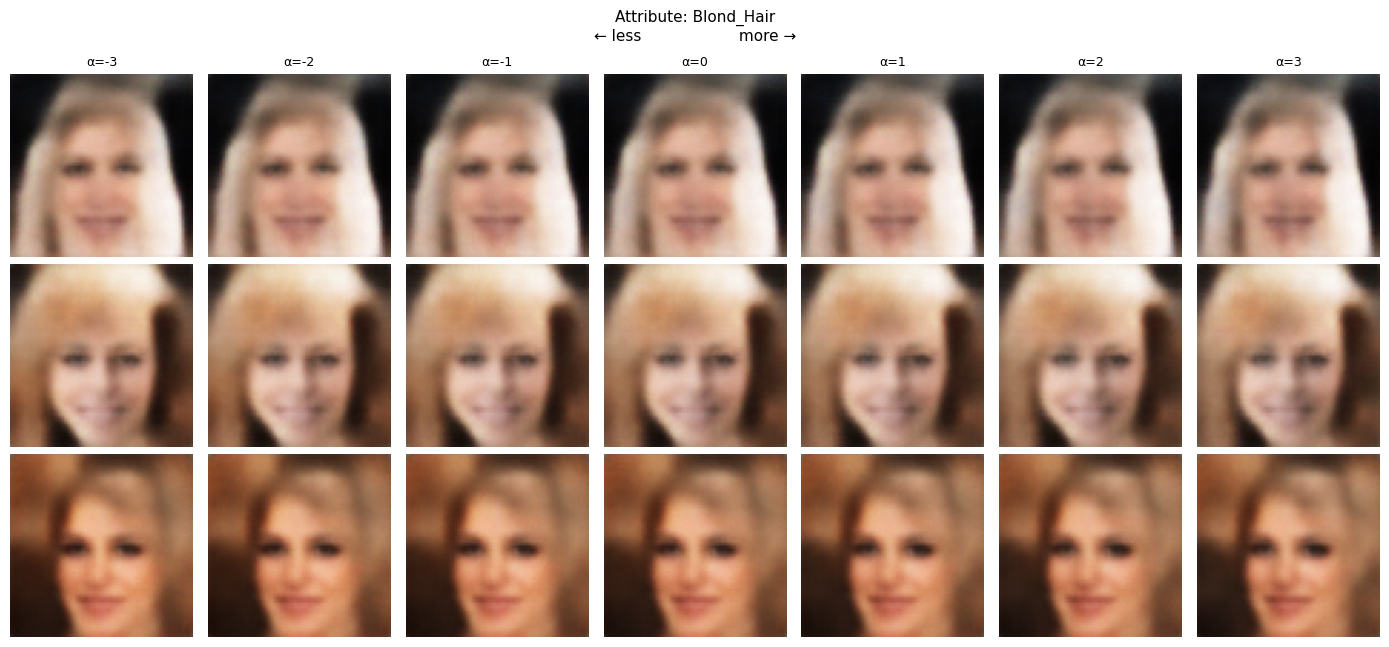

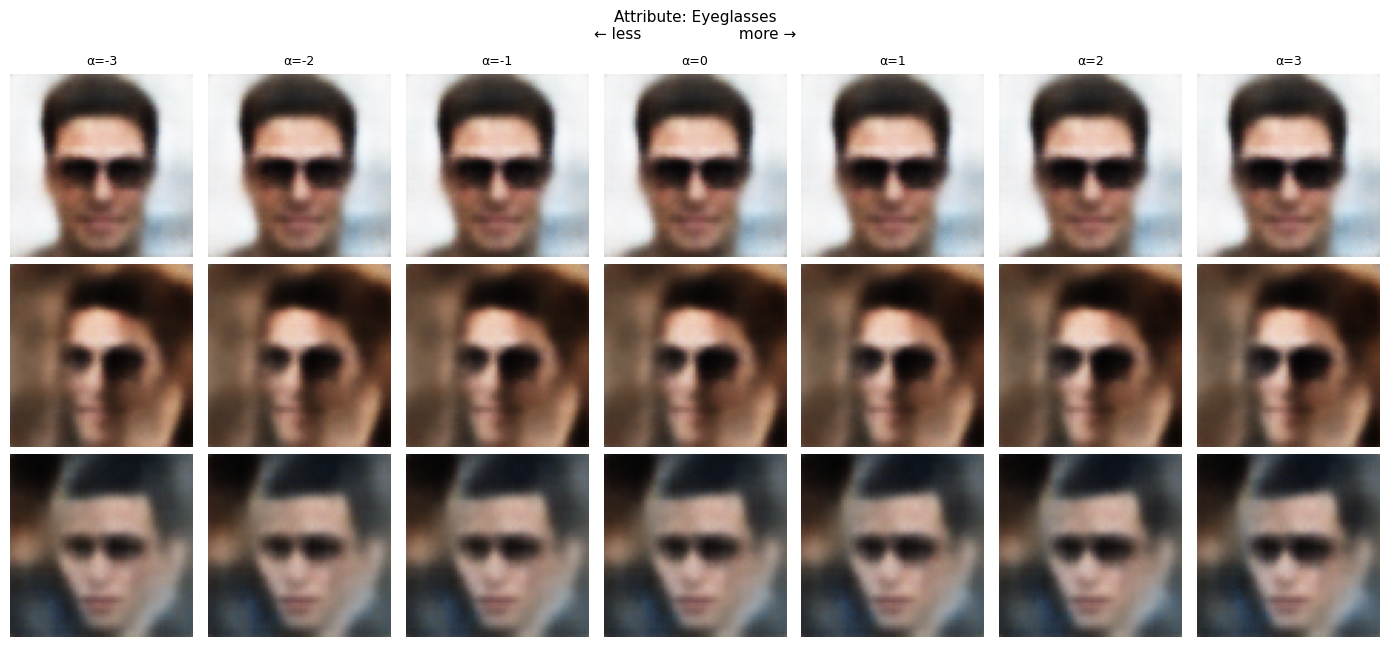

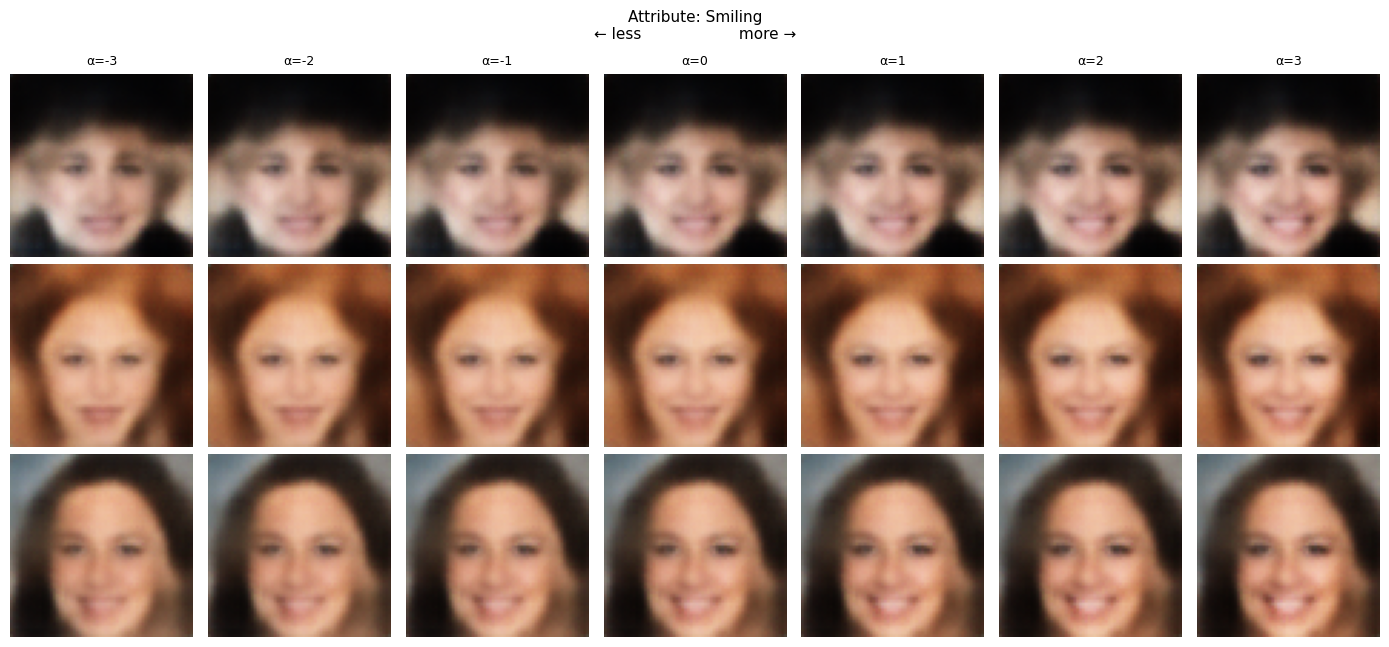

In [44]:
# Manipulation Strips

def manipulate_and_visualise(vae, test_mus, test_attrs,
                              directions, scaler,
                              attr_names, n_images=3):
    alphas   = [-3, -2, -1, 0, 1, 2, 3]
    n_alphas = len(alphas)
    vae.eval()

    for attr_idx, attr_name in enumerate(attr_names):
        w   = directions[attr_name]
        fig, axes = plt.subplots(
            n_images, n_alphas,
            figsize=(n_alphas * 2, n_images * 2.2))

        attr_col = test_attrs[:, attr_idx]
        pos_idxs = np.where(attr_col == 1)[0][:n_images]

        for row, img_idx in enumerate(pos_idxs):
            z_orig    = test_mus[img_idx]
            z_orig_sc = scaler.transform(
                z_orig.reshape(1, -1))[0]

            for col, alpha in enumerate(alphas):
                z_moved  = z_orig_sc + alpha * w
                z_moved  = scaler.inverse_transform(
                    z_moved.reshape(1, -1))
                z_tensor = torch.tensor(
                    z_moved, dtype=torch.float32).to(device)

                with torch.no_grad():
                    img_out = vae.decode(z_tensor)[0]

                img_np = img_out.cpu().permute(1, 2, 0).numpy()
                img_np = (img_np + 1) / 2
                img_np = np.clip(img_np, 0, 1)

                axes[row, col].imshow(img_np)
                axes[row, col].axis('off')

                if row == 0:
                    axes[row, col].set_title(
                        f'α={alpha}', fontsize=9)

        fig.suptitle(
            f'Attribute: {attr_name}\n'
            f'← less                    more →',
            fontsize=11)
        plt.tight_layout()
        plt.savefig(f'manip_{attr_name}_4_3.png', dpi=150)
        plt.show()


manipulate_and_visualise(
    vae, test_mus, test_attrs,
    directions, scaler, TARGET_ATTRS, n_images=3)

# Interpretation And Observation

#### The SVM directions found in the VAE latent space produce coherent attribute manipulations across all three attributes — blond hair, eyeglasses, and smiling — with the manipulation strength directly proportional to α and the face identity remaining largely consistent across the strip. Eyeglasses achieves the highest SVM accuracy at 95.7% and produces the cleanest visual manipulation because glasses are a spatially localised binary object that leaves a strong consistent signature in latent space, making its separating hyperplane easy to find. Blond hair at 91.9% produces a smooth colour transition because hair colour is a strong low-frequency signal that the encoder reliably captures. Smiling at 85.5% is the subtlest — it involves distributed changes across mouth, cheek, and eye geometry rather than a localised object, so its latent direction is less clean and the visual effect less dramatic. The fact that all three work at all — with only 5 epochs of unsupervised VAE training — confirms that the latent space has organised itself around semantically meaningful structure as a side effect of learning to reconstruct faces faithfully. This directly motivates LDAE's semantic encoder design: rather than finding attribute directions post-hoc via SVM, LDAE learns a continuous semantic embedding y_sem that captures the full semantic content of a brain MRI in a single forward pass, enabling not just attribute detection but conditioning the entire diffusion trajectory on semantic content.

### Understanding it better

**The VAE** compresses each face image into a 128-dimensional vector — think of it as 128 numbers that fully describe that face. It learns this compression by training on reconstruction — encode the image to 128 numbers, decode back, minimise the difference. The KL term forces these vectors to not be scattered randomly but sit in a structured continuous space.

**The latent space** is that 128-dimensional space where every face lives as a point. Because of the KL regularisation, similar faces sit near each other — blonde faces cluster together, faces with glasses cluster together.

**The SVM** draws a flat dividing plane (hyperplane) through this 128-dimensional space that best separates blonde vs non-blonde points. The normal vector to this plane — called w — is the direction in space that most strongly corresponds to "blondeness."

**The manipulation** moves a point along that direction:
```
z_new = z  +  α · w
```
Increasing α moves the point further into blonde territory. Decreasing α moves it away. Then you decode z_new back to an image — and the face comes out with the attribute shifted accordingly, while everything else stays roughly the same because you only moved in one specific direction.

**The key insight** — this only works because the latent space is smooth and continuous. Moving along w passes through meaningful intermediate points rather than nonsense. That smoothness is entirely because of the KL term forcing the space to be dense and well-behaved.